# PCB ANOMALY DETECTION AND SEGMENTATION

In [1]:
!pip install segmentation-models-pytorch albumentations -q

import torch

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


 # Data Loading

In [2]:
import os

normal_dir  = "/content/drive/MyDrive/Vision/pcb4/Normal"
anomaly_dir = "/content/drive/MyDrive/Vision/pcb4/Anomaly"
mask_dir    = "/content/drive/MyDrive/Vision/pcb4/Anomaly/Masks"

all_images = []
all_masks = []

# Add normal images
for f in os.listdir(normal_dir):
    if f.endswith(".JPG"):
        all_images.append(os.path.join(normal_dir, f))
        all_masks.append(None)  # None indicates a normal image

# Add anomaly images along with their masks
for f in os.listdir(anomaly_dir):
    if f.endswith(".JPG"):
        img_path = os.path.join(anomaly_dir, f)
        mask_path = os.path.join(mask_dir, os.path.splitext(f)[0] + ".png")
        if os.path.exists(mask_path):
            all_images.append(img_path)
            all_masks.append(mask_path)

print(f"Total Normal Images: {all_masks.count(None)}")
print(f"Total Anomaly Images: {len(all_masks) - all_masks.count(None)}")

Total Normal Images: 1005
Total Anomaly Images: 100


# Data Analysis

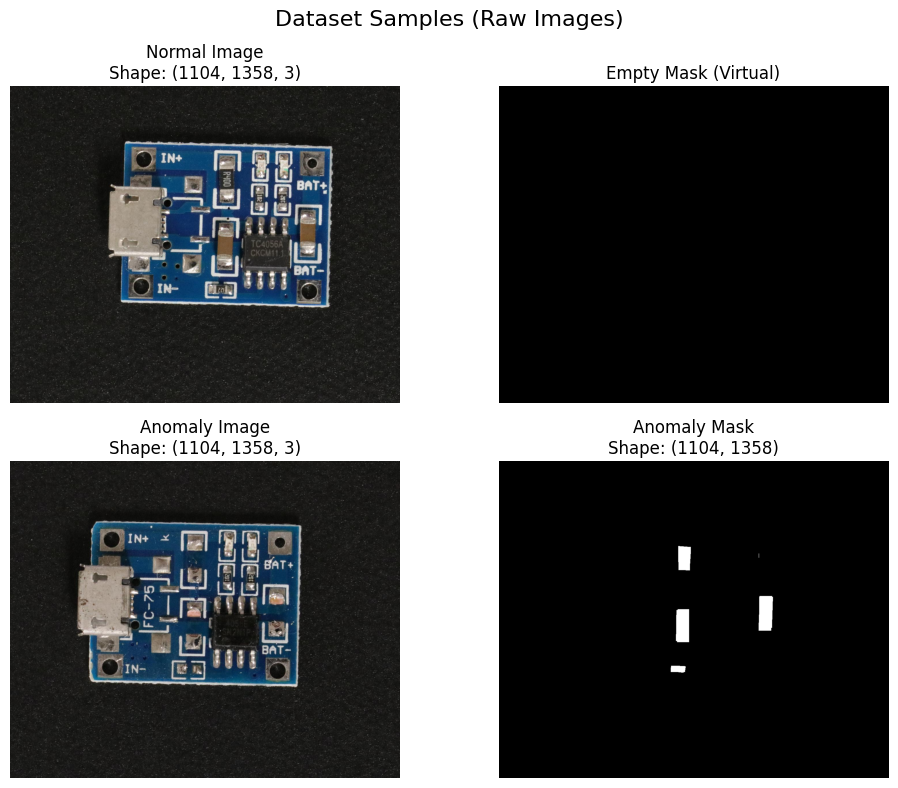

In [3]:
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np

# Visualize random normal and anomaly images
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Dataset Samples (Raw Images)', fontsize=16)

# Normal Sample
normal_samples = [img for img in all_images if 'Normal' in img]
if normal_samples:
    sample_normal = random.choice(normal_samples)
    img_n = cv2.imread(sample_normal)
    img_n = cv2.cvtColor(img_n, cv2.COLOR_BGR2RGB)

    axes[0, 0].imshow(img_n)
    axes[0, 0].set_title(f"Normal Image\nShape: {img_n.shape}")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(np.zeros(img_n.shape[:2]), cmap='gray')
    axes[0, 1].set_title("Empty Mask (Virtual)")
    axes[0, 1].axis('off')

# Anomaly Sample
anomaly_indices = [i for i, mask in enumerate(all_masks) if mask is not None]
if anomaly_indices:
    idx = random.choice(anomaly_indices)
    img_a = cv2.imread(all_images[idx])
    img_a = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
    mask_a = cv2.imread(all_masks[idx], cv2.IMREAD_GRAYSCALE)

    axes[1, 0].imshow(img_a)
    axes[1, 0].set_title(f"Anomaly Image\nShape: {img_a.shape}")
    axes[1, 0].axis('off')

    axes[1, 1].imshow(mask_a, cmap='gray')
    axes[1, 1].set_title(f"Anomaly Mask\nShape: {mask_a.shape}")
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Data Split

In [4]:
from sklearn.model_selection import train_test_split

# Split into Train, Validation, and Test
X_train, X_test, m_train, m_test = train_test_split(
    all_images, all_masks, test_size=0.2, random_state=42)

X_train, X_val, m_train, m_val = train_test_split(
    X_train, m_train, test_size=0.1, random_state=42)

print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Train samples: 795
Validation samples: 89
Test samples: 221


# Augmentation

In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print("Augmentation transforms defined.")

Augmentation transforms defined.


# Custom Dataset Class

In [6]:
from torch.utils.data import Dataset

class PCBSegDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = self.masks[idx]

        # Read image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read or create mask
        if mask_path is None:
            # Normal image, create an all-black mask
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        else:
            # Anomaly image, read the mask
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype(np.uint8)  # Strict binarization

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = mask.unsqueeze(0).float()  # Add channel dimension
        return image, mask

print("PCBSegDataset class defined.")

PCBSegDataset class defined.


# DataLoaders

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    PCBSegDataset(X_train, m_train, train_transform),
    batch_size=8,
    shuffle=True)

val_loader = DataLoader(
    PCBSegDataset(X_val, m_val, val_transform),
    batch_size=8,
    shuffle=False)

test_loader = DataLoader(
    PCBSegDataset(X_test, m_test, val_transform),
    batch_size=8,
    shuffle=False)

print("DataLoaders Ready")

DataLoaders Ready


# Model Definition

In [8]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

print("Model initialized.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Model initialized.


# Loss Function and Optimizer

In [9]:
import torch.nn as nn

loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
bce_fn = nn.BCEWithLogitsLoss()

def criterion(y_pred, y_true):
    return 0.5 * bce_fn(y_pred, y_true) + 0.5 * loss_fn(y_pred, y_true)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5)

print("Loss and Optimizer define.")

Loss and Optimizer define.


# Training Loop

In [10]:
EPOCHS = 70
best_val_loss = float('inf')

# Parameters to find the knee point (plateau)
min_delta = 0.003       # Minimum required improvement
patience = 5            # Number of epochs to wait for an improvement
patience_counter = 0    # Counter for epochs without significant improvement
knee_point_saved = False # Flag to make sure we only save the model once

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Step the scheduler based on validation loss
    scheduler.step(avg_val_loss)

    status = ""

    # Check for the knee point if we haven't saved the model yet
    if not knee_point_saved:
        # Check if the loss improved by at least min_delta
        if best_val_loss - avg_val_loss > min_delta:
            best_val_loss = avg_val_loss
            patience_counter = 0 # Reset counter because we had a good improvement
        else:
            patience_counter += 1 # No significant improvement

        # If we waited enough epochs, we are slightly after the knee point
        if patience_counter >= patience:
            torch.save(model.state_dict(), "knee_pcb_model.pth")
            status = "-> Knee Point Model Saved!"
            knee_point_saved = True # Set flag to True so it stops saving

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} {status}")

print("\nTraining complete!")
if knee_point_saved:
    print("Model was successfully saved at (or slightly after) the knee point.")
else:
    print("Knee point was not detected. You might need to adjust min_delta or patience.")

Epoch 01/70 | Train Loss: 0.4062 | Val Loss: 0.3815 
Epoch 02/70 | Train Loss: 0.3408 | Val Loss: 0.3468 
Epoch 03/70 | Train Loss: 0.3297 | Val Loss: 0.3240 
Epoch 04/70 | Train Loss: 0.2939 | Val Loss: 0.3156 
Epoch 05/70 | Train Loss: 0.2685 | Val Loss: 0.2924 
Epoch 06/70 | Train Loss: 0.2771 | Val Loss: 0.2851 
Epoch 07/70 | Train Loss: 0.2388 | Val Loss: 0.2684 
Epoch 08/70 | Train Loss: 0.2379 | Val Loss: 0.2615 
Epoch 09/70 | Train Loss: 0.2031 | Val Loss: 0.2602 
Epoch 10/70 | Train Loss: 0.2313 | Val Loss: 0.2147 
Epoch 11/70 | Train Loss: 0.1800 | Val Loss: 0.2030 
Epoch 12/70 | Train Loss: 0.1871 | Val Loss: 0.2141 
Epoch 13/70 | Train Loss: 0.1967 | Val Loss: 0.1991 
Epoch 14/70 | Train Loss: 0.1735 | Val Loss: 0.2118 
Epoch 15/70 | Train Loss: 0.1572 | Val Loss: 0.1767 
Epoch 16/70 | Train Loss: 0.1691 | Val Loss: 0.1901 
Epoch 17/70 | Train Loss: 0.1443 | Val Loss: 0.1786 
Epoch 18/70 | Train Loss: 0.1712 | Val Loss: 0.1800 
Epoch 19/70 | Train Loss: 0.1508 | Val Loss: 0

# Plot Training Loss

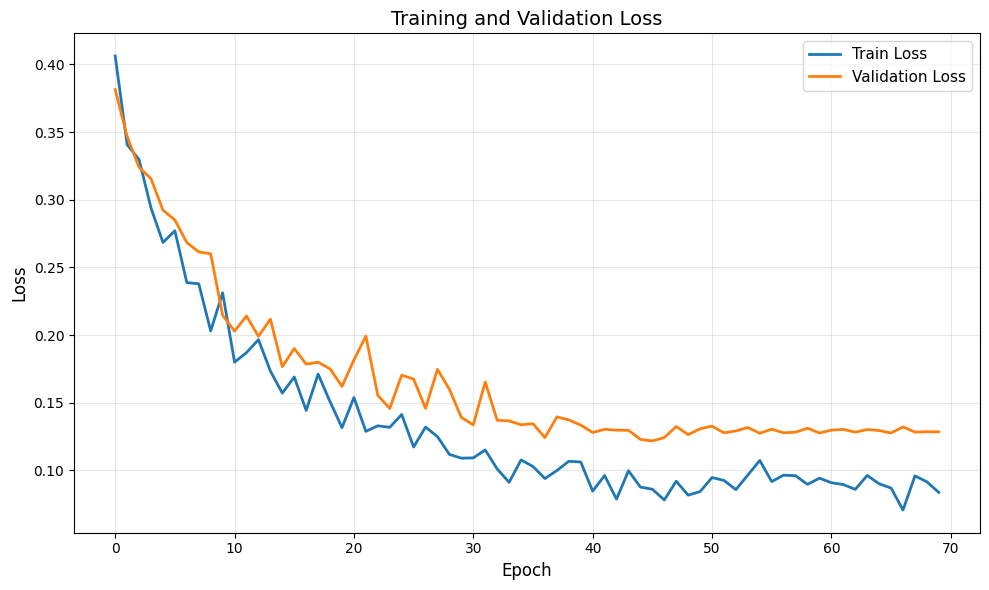

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Output Samples

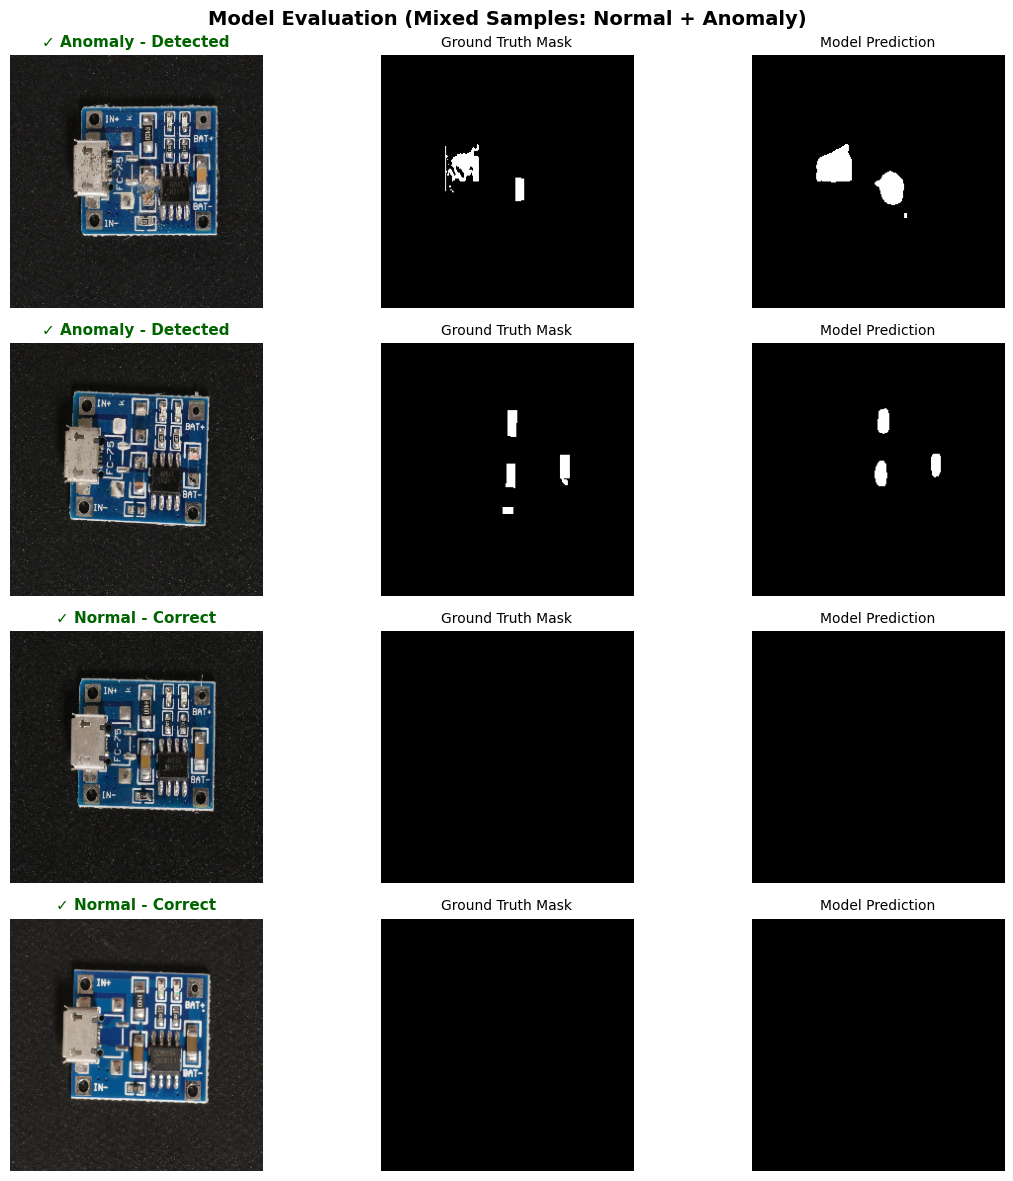

In [15]:
model_path = "best_pcb_model.pth"
if not os.path.exists(model_path):
    print(f"Error: Model file '{model_path}' not found.")
else:
    # Load the best model
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # Direct access to test dataset
    test_dataset = test_loader.dataset

    # Find indices of NORMAL and ANOMALY samples
    normal_indices = [i for i in range(len(test_dataset)) if m_test[i] is None]
    anomaly_indices = [i for i in range(len(test_dataset)) if m_test[i] is not None]

    # Select random samples from both categories
    num_normal = min(2, len(normal_indices))
    num_anomaly = min(2, len(anomaly_indices))

    if num_normal > 0:
        selected_normal = random.sample(normal_indices, num_normal)
    else:
        selected_normal = []

    if num_anomaly > 0:
        selected_anomaly = random.sample(anomaly_indices, num_anomaly)
    else:
        selected_anomaly = []

    # Combine all indices (anomaly first, then normal)
    all_indices = selected_anomaly + selected_normal
    num_samples = len(all_indices)

    if num_samples == 0:
        print("No samples available in test set.")
    else:
        images_list = []
        masks_list = []
        sample_types = []  # Track which samples are anomaly vs normal

        # Extract images and masks
        for idx in all_indices:
            img, mask = test_dataset[idx]
            images_list.append(img)
            masks_list.append(mask)
            sample_types.append('Anomaly' if m_test[idx] is not None else 'Normal')

        # Stack images and move to device
        images = torch.stack(images_list).to(device)
        masks = torch.stack(masks_list).to(device)

        # Model prediction
        with torch.no_grad():
            preds = model(images)
            preds = torch.sigmoid(preds)  # Convert to probability

        # Move to CPU and transform for visualization
        images_np = images.cpu().numpy().transpose(0, 2, 3, 1)
        masks_np = masks.cpu().numpy()
        preds_np = (preds.cpu().numpy() > 0.5).astype(np.uint8)  # Threshold 0.5

        # Plot images
        fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3 * num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)

        fig.suptitle("Model Evaluation (Mixed Samples: Normal + Anomaly)",
                     fontsize=14, fontweight='bold')

        # Denormalize for display
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        for i in range(num_samples):
            img_display = std * images_np[i] + mean
            img_display = np.clip(img_display, 0, 1)

            # Determine status based on sample type and prediction
            anomaly_detected = preds_np[i].max() > 0
            sample_type = sample_types[i]

            if sample_type == 'Anomaly':
                # This is an anomaly sample
                if anomaly_detected:
                    status_text = f"✓ {sample_type} - Detected"
                    status_color = "darkgreen"
                else:
                    status_text = f"✗ {sample_type} - Missed"
                    status_color = "darkred"
            else:
                # This is a normal sample
                if anomaly_detected:
                    status_text = f"✗ {sample_type} - False Positive"
                    status_color = "darkred"
                else:
                    status_text = f"✓ {sample_type} - Correct"
                    status_color = "darkgreen"

            # Column 1: Input image with status
            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title(status_text, color=status_color, fontweight='bold', fontsize=11)
            axes[i, 0].axis('off')

            # Column 2: Ground Truth Mask
            axes[i, 1].imshow(masks_np[i, 0], cmap='gray')
            axes[i, 1].set_title("Ground Truth Mask", fontsize=10)
            axes[i, 1].axis('off')

            # Column 3: Model Prediction
            axes[i, 2].imshow(preds_np[i, 0], cmap='gray')
            axes[i, 2].set_title("Model Prediction", fontsize=10)
            axes[i, 2].axis('off')

        plt.tight_layout()
        plt.show()